## Importing libraries

In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import os
import fiona
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd

In [2]:
print("Shapely:", shapely.__version__)
print("GeoPandas:", gpd.__version__)
print("Fiona:", fiona.__version__)

#Versions in the standard environment (environment1) for running the model have issues for reading the files with geopandas
#Updates are required and a copy environment (environment2) is used to execute this notebook (geopandas should be >0.10)

Shapely: 1.8.0
GeoPandas: 0.13.2
Fiona: 1.8.20


## Relevant file paths

In [3]:
#Load country map border
map_border =  str(os.path.dirname(os.getcwd())) + r'\\1. MSR Creator\\Input\\AllCountryBoundaries_GAUL.shp'

#Load rough MSR shapes for each technology (before cost assignement)
S1_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\1. MSR Creator\Output\Bolivia\Stage4_MSR\solarpv_FinalMSRs.shp'
S1_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\1. MSR Creator\Output\Bolivia\Stage4_MSR\wind_FinalMSRs.shp'

#Load prescreened MSR shapes (with LCOE and CAPEX values defined) 
S3_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia\SolarPV_prescreen.shp'
S3_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia\Wind_prescreen.shp'

#Load screened MSR data sets with hourly availabilities (for the top % of resources) 
S4_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\4. Screener\Results-Screened_Bolivia\SolarPV_BestMSRsToCover5%CountryArea.shp'
S4_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\4. Screener\Results-Screened_Bolivia\Wind_BestMSRsToCover5%CountryArea.shp'


In [4]:
with fiona.open(S3_MSR_pv_file) as src:
    print(src.schema)
    print(src.crs)
    print(len(src))

{'properties': OrderedDict([('FID', 'int:18'), ('AreakM2', 'float:24.15'), ('CapacityMW', 'float:24.15'), ('RoadDist', 'float:24.15'), ('T_Dist_gf', 'float:24.15'), ('D_Dist_gf', 'float:24.15'), ('TD_Dist_gf', 'float:24.15'), ('SubstnDist', 'float:24.15'), ('Load_dst', 'float:24.15'), ('City_name', 'str:80'), ('City_Pop', 'float:24.15'), ('CtLst100kM', 'str:80'), ('CtCnt100kM', 'int:18'), ('PopIn100kM', 'float:24.15'), ('Elev_mean', 'float:24.15'), ('Elev_max', 'float:24.15'), ('Elev_centr', 'float:24.15'), ('CtryName', 'str:80'), ('GHIkWhm2d', 'str:80'), ('RawERA_GHI', 'float:24.15'), ('CorAdderWh', 'float:24.15'), ('CF', 'float:24.15'), ('Y_GWh', 'float:24.15'), ('sLCOE-MWh', 'float:24.15'), ('tLCOE-MWh', 'float:24.15'), ('tCAPEX-kW', 'float:24.15'), ('rLCOE-MWh', 'float:24.15'), ('rCAPEX-kW', 'float:24.15'), ('LCOE-MWh', 'float:24.15'), ('trCAPEX-kW', 'float:24.15')]), 'geometry': 'Polygon'}
{}
2723


In [5]:
# Read data without geometry (to work with environment1) 
gdf_test = gpd.read_file(S3_MSR_pv_file, ignore_geometry=True)
gdf_test.head()

,FID,AreakM2,CapacityMW,RoadDist,T_Dist_gf,D_Dist_gf,TD_Dist_gf,SubstnDist,Load_dst,City_name,...,CorAdderWh,CF,Y_GWh,sLCOE-MWh,tLCOE-MWh,tCAPEX-kW,rLCOE-MWh,rCAPEX-kW,LCOE-MWh,trCAPEX-kW
0,0,323.570977,1067.784224,2.517567,26.134085,2.035956,2.035956,18.986937,32.207742,Desaguadero,...,18.805593,24.006560,2245.523143,54.355021,5.040280,103.653836,1.148711,21.927504,60.544012,125.581340
1,1,444.000524,1465.201730,2.187198,42.425095,2.252934,2.252934,39.248551,22.364214,Desaguadero,...,13.437417,23.783817,3052.692655,54.864073,5.934486,120.910903,1.007318,19.050061,61.805877,139.960964
2,2,625.001550,2062.505114,2.110642,63.748736,2.599523,2.599523,67.318276,39.185667,Desaguadero,...,3.826399,23.824734,4304.544451,54.769849,7.031049,143.499036,0.970390,18.383266,62.771288,161.882302
3,3,710.594882,2344.963112,1.916101,69.377918,3.519774,3.519774,92.519085,62.497181,Desaguadero,...,-5.030880,23.519716,4831.391094,55.480137,7.418191,149.462029,0.892372,16.688857,63.790700,166.150886
4,4,715.690942,2361.780109,2.454330,78.509071,4.645491,4.645491,114.239061,88.011353,Desaguadero,...,-0.337021,23.628467,4888.539344,55.224787,7.861916,159.134659,1.137777,21.376728,64.224481,180.511387


## Plotting functions

In [6]:
def region_map (geo_dataframe, country, key_column, map_title):
    """
    Creates a simple heat map of a specific country for the selected column/parameter.
    """
    gdfmap = gpd.read_file(map_border)
    gdf_country = gdfmap[gdfmap['name'] == country]

    ax = geo_dataframe.plot(column=key_column, legend=True, figsize=(8,6), cmap='viridis')
    gdf_country.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
    
    plt.title(map_title)
    plt.show()


In [7]:
def plot_variable_relationship(dataframe, col_x, col_y, add_regression=True):
    """
    Plots the relationship between two variables in a dataframe.
    
    Parameters:
    - df: pandas DataFrame
    - col_x: column name for the independent variable (x-axis)
    - col_y: column name for the dependent variable (y-axis)
    - add_regression: if True, adds a linear regression line
    """

    x = pd.to_numeric(dataframe[col_x], errors="coerce").to_numpy().ravel()
    y = pd.to_numeric(dataframe[col_y], errors="coerce").to_numpy().ravel()

    # ---- FIX: remove non-finite values before regression ----
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    # --- Compute Pearson & Spearman correlations ---
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    print(f"\n===== Correlation Analysis: {col_x} vs {col_y} =====")
    print(f"Pearson r:     {pearson_r:.4f}  (p = {pearson_p:.4e})")
    print(f"Spearman rho:  {spearman_rho:.4f}  (p = {spearman_p:.4e})")
    print("=====================================================\n")

    fig, ax = plt.subplots(figsize=(8, 4))

    # Scatter plot
    ax.scatter(x, y, color='blue', alpha=0.6, edgecolor='k', s=60)
    
    # Optional: add linear regression
    if add_regression:
        coeffs = np.polyfit(x, y, deg=1)  # linear regression
        y_fit = np.polyval(coeffs, x)
        ax.plot(x, y_fit, color='red', linestyle='--', linewidth=2,
                label=f'Linear fit: y={coeffs[0]:.2f}x + {coeffs[1]:.2f}')
        ax.legend()
        
    # Add correlation info on the plot (top-left corner)
    corr_text = (
        f"Pearson r = {pearson_r:.3f}\n"
        f"Spearman ρ = {spearman_rho:.3f}"
    )
    ax.text(
        0.02, 0.98, corr_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
    )

    ax.set_title(f"Relationship between {col_x} and {col_y}")
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)
    ax.grid(True)
    
    plt.show()


In [8]:
def generate_supply_curve(geo_dataframe,ranking_col,accumulation_col,ascending=True,):
    """
    Creates a supply curve by sorting a dataframe (geo_dataframe) based on [ranking_col] and 
    accumulating values based on [accumulation_col], using matplotlib.
    """

    # Copy to avoid altering original
    df = geo_dataframe[[ranking_col, accumulation_col]].copy()

    # Sort by chosen metric
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)

    # Create cumulative sum
    df["cumulative"] = df[accumulation_col].cumsum()

    # Matplotlib figure
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(df["cumulative"], df[ranking_col], marker='o', linestyle='-')
    
    ax.set_title(f"Supply Curve: {ranking_col} vs cumulative {accumulation_col}")
    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(f"{ranking_col}")

    ax.grid(True)
    
    plt.show()

In [9]:
def generate_supply_curve_color(geo_dataframe, ranking_col, accumulation_col, third_col,
                                ascending=True, cmap="viridis"):
    df = geo_dataframe[[ranking_col, accumulation_col, third_col]].copy()
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)
    df["cumulative"] = df[accumulation_col].cumsum()

    fig, ax = plt.subplots(figsize=(8, 4))

    sc = ax.scatter(
        df["cumulative"],
        df[ranking_col],
        c=df[third_col],
        cmap=cmap
    )

    ax.plot(df["cumulative"], df[ranking_col], alpha=0.3)  # keep curve shape visible

    cbar = plt.colorbar(sc)
    cbar.set_label(third_col)

    ax.set_title(f"Supply Curve Colored by {third_col}")
    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(ranking_col)
    ax.grid(True)

    plt.show()

    return df


In [10]:
from mpl_toolkits.mplot3d import Axes3D

def generate_supply_curve_3d(geo_dataframe, ranking_col, accumulation_col, third_col,
                             ascending=True):
    """
    3D supply curve: cumulative vs ranking vs third variable.
    """
    
    df = geo_dataframe[[ranking_col, accumulation_col, third_col]].copy()
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)
    df["cumulative"] = df[accumulation_col].cumsum()
    
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(
        df["cumulative"], 
        df[ranking_col], 
        df[third_col],
        c=df[third_col],
        s=3
    )

    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(ranking_col)
    ax.set_zlabel(third_col)
    ax.set_title(f"3D Supply Curve with {third_col}")

    plt.show()

    return df


In [43]:
def generate_supply_curve_3d_band_analysis(geo_dataframe, ranking_col,
                                           accumulation_col, third_col,
                                           n_bands, ascending=True, 
                                           cmap="viridis"):
    """
    3D supply curve band analysis based on quantiles of third_col.
    Creates n_bands supply curves (bands) based on quantile ranges of the third variable.
    """

    df = geo_dataframe[[ranking_col, accumulation_col, third_col]].copy()

    # Create quantile bands
    df["band"] = pd.qcut(df[third_col], q=n_bands, labels=False, duplicates="drop")
    df = df.dropna(subset=["band"])

    # Prepare figure
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection="3d")

    # Choose color map
    colors = plt.cm.get_cmap(cmap, n_bands)

    # Plot each band separately
    for band in sorted(df["band"].unique()):
        df_band = df[df["band"] == band].copy()
        df_band = df_band.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)
        df_band["cumulative"] = df_band[accumulation_col].cumsum()

        # Use average altitude (or third_col) for the whole curve
        z_val = df_band[third_col].mean()
        z_array = np.full_like(df_band["cumulative"], fill_value=z_val)

        ax.plot(
            df_band["cumulative"],
            df_band[ranking_col],
            z_array,#df_band["band"],
            label=f"Band {band} (mean quantile value = {z_val:.2f})",
            #color=colors(band)
        )

        # optional: scatter for points
        ax.scatter(
            df_band["cumulative"],
            df_band[ranking_col],
            df_band[third_col],
            #color=colors(band),
            s=3,
            alpha=0.5,
            depthshade=True,
        )
    
    # ax.zaxis._axinfo["grid"]['linewidth'] = 0.5
    # ax.zaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5,0.3)

    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)

    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(ranking_col)
    ax.set_zlabel(third_col)
    ax.set_title(f"3D Supply Curve Band Analysis by {third_col}")

    ax.legend(fontsize=5) #'small'
    plt.show()

    return df

In [50]:
def generate_supply_curve_3d_definedband_analysis(
    geo_dataframe,
    ranking_col,
    accumulation_col,
    third_col,
    band_edges,               # <-- user-defined
    ascending=True,
    cmap="viridis"
):
    """
    3D supply curve band analysis using user-defined bands of third_col.

    Parameters
    ----------
    band_edges : list or array
        Monotonically increasing bin edges for third_col
        e.g. [0, 200, 500, 1000, np.inf]
    """

    df = geo_dataframe[[ranking_col, accumulation_col, third_col]].copy()

    # Create bands using explicit thresholds
    df["band"] = pd.cut(
        df[third_col],
        bins=band_edges,
        labels=False,
        include_lowest=True
    )

    df = df.dropna(subset=["band"])
    df["band"] = df["band"].astype(int)

    # Prepare figure
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection="3d")

    n_bands = len(band_edges) - 1
    colors = plt.cm.get_cmap(cmap, n_bands)

    for band in sorted(df["band"].unique()):
        df_band = df[df["band"] == band].copy()
        df_band = df_band.sort_values(
            ranking_col, ascending=ascending
        ).reset_index(drop=True)

        df_band["cumulative"] = df_band[accumulation_col].cumsum()

        z_val = df_band[third_col].mean()
        z_array = np.full(len(df_band), z_val)

        ax.plot(
            df_band["cumulative"],
            df_band[ranking_col],
            z_array,
            label=f"Band {band} [{band_edges[band]}, {band_edges[band+1]})",
            color=colors(band)
        )

        ax.scatter(
            df_band["cumulative"],
            df_band[ranking_col],
            df_band[third_col],
            color=colors(band),
            s=3,
            alpha=0.5,
            depthshade=True
        )

    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)

    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(ranking_col)
    ax.set_zlabel(third_col)
    ax.set_title(f"3D Supply Curve Band Analysis by {third_col}")

    ax.legend(fontsize=6)
    plt.show()

    return df


## Basic file exploration

In [12]:
gdf3wind = gpd.read_file(S3_MSR_wind_file)
gdf3solar = gpd.read_file(S3_MSR_pv_file)

#check cordinate reference system and change it to WGS84 ellipsoid
gdf3wind = gdf3wind.to_crs("EPSG:4326")
gdf3solar = gdf3solar.to_crs("EPSG:4326")
#gdf3solar.crs

In [13]:
gdf3solar.info()
gdf3wind.columns
#gdf3wind.info()
#gdf3wind.columns

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2723 entries, 0 to 2722
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         2723 non-null   int64   
 1   AreakM2     2723 non-null   float64 
 2   CapacityMW  2723 non-null   float64 
 3   RoadDist    2723 non-null   float64 
 4   T_Dist_gf   2723 non-null   float64 
 5   D_Dist_gf   2723 non-null   float64 
 6   TD_Dist_gf  2723 non-null   float64 
 7   SubstnDist  2723 non-null   float64 
 8   Load_dst    2723 non-null   float64 
 9   City_name   2723 non-null   object  
 10  City_Pop    2723 non-null   float64 
 11  CtLst100kM  1994 non-null   object  
 12  CtCnt100kM  2723 non-null   int64   
 13  PopIn100kM  2723 non-null   float64 
 14  Elev_mean   2721 non-null   float64 
 15  Elev_max    2721 non-null   float64 
 16  Elev_centr  2723 non-null   float64 
 17  CtryName    2723 non-null   object  
 18  GHIkWhm2d   2723 non-null   object  
 19

Index(['FID', 'AreakM2', 'CapacityMW', 'RoadDist', 'T_Dist_gf', 'D_Dist_gf',
       'TD_Dist_gf', 'SubstnDist', 'Load_dst', 'City_name', 'City_Pop',
       'CtLst100kM', 'CtCnt100kM', 'PopIn100kM', 'Elev_mean', 'Elev_max',
       'Elev_centr', 'CtryName', 'MeanSpeed', 'IEC_Class', 'ERA_WSpeed',
       'CF100m', 'Y_GWh100m', 'sLCOE-MWh', 'tLCOE-MWh', 'tCAPEX-kW',
       'rLCOE-MWh', 'rCAPEX-kW', 'LCOE-MWh', 'trCAPEX-kW', 'geometry'],
      dtype='object')

In [14]:
height = gdf3wind["Elev_mean"]

In [15]:
#gdf3solar.head()
gdf3wind.head()

,FID,AreakM2,CapacityMW,RoadDist,T_Dist_gf,D_Dist_gf,TD_Dist_gf,SubstnDist,Load_dst,City_name,...,CF100m,Y_GWh100m,sLCOE-MWh,tLCOE-MWh,tCAPEX-kW,rLCOE-MWh,rCAPEX-kW,LCOE-MWh,trCAPEX-kW,geometry
0,0,152.806260,449.250405,1.201183,6.791024,2.393051,2.393051,34.994978,21.379872,Montero,...,44.935736,1768.416018,47.380638,2.160436,83.163732,0.292804,10.462067,49.833877,93.625799,"POLYGON ((-63.38956 -17.46986, -63.38647 -17.4..."
1,1,209.618699,616.278976,1.244803,3.597729,2.410556,2.410556,19.970997,15.999640,Santa Cruz1,...,46.473415,2508.915559,45.812941,2.003985,79.781074,0.293397,10.841983,48.110323,90.623057,"POLYGON ((-63.41391 -17.61098, -63.41082 -17.6..."
2,2,22.950870,67.475558,0.711849,11.408714,0.888841,0.888841,15.603627,10.721693,Santa Cruz1,...,43.952669,259.798023,41.734873,2.338671,88.055250,0.177404,6.200061,44.250948,94.255311,"POLYGON ((-63.32942 -17.87104, -63.33174 -17.8..."
3,3,278.516488,818.838475,0.608752,8.425069,1.252322,1.252322,30.386299,24.486972,Montero,...,45.037951,3230.583491,47.273106,2.200397,84.894676,0.148054,5.302104,49.621557,90.196780,"POLYGON ((-63.25947 -17.55403, -63.25893 -17.5..."
4,4,252.448276,742.197930,0.649362,2.751796,2.260233,2.260233,11.733223,11.284314,Santa Cruz1,...,41.020855,2667.034008,44.717719,2.244858,78.884977,0.173397,5.655814,47.135974,84.540791,"POLYGON ((-63.28986 -17.72242, -63.28932 -17.7..."


## Data analysis (for prescreend or S3 data)

In [62]:
gdf3wind = gpd.read_file(S3_MSR_wind_file)
gdf3solar = gpd.read_file(S3_MSR_pv_file)

#check cordinate reference system and change it to WGS84 ellipsoid
gdf3wind = gdf3wind.to_crs("EPSG:4326")
gdf3solar = gdf3solar.to_crs("EPSG:4326")
#gdf3solar.crs

In [63]:
gdf3solar.info()
gdf3wind.columns
#gdf3wind.info()
#gdf3wind.columns

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2723 entries, 0 to 2722
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         2723 non-null   int64   
 1   AreakM2     2723 non-null   float64 
 2   CapacityMW  2723 non-null   float64 
 3   RoadDist    2723 non-null   float64 
 4   T_Dist_gf   2723 non-null   float64 
 5   D_Dist_gf   2723 non-null   float64 
 6   TD_Dist_gf  2723 non-null   float64 
 7   SubstnDist  2723 non-null   float64 
 8   Load_dst    2723 non-null   float64 
 9   City_name   2723 non-null   object  
 10  City_Pop    2723 non-null   float64 
 11  CtLst100kM  1994 non-null   object  
 12  CtCnt100kM  2723 non-null   int64   
 13  PopIn100kM  2723 non-null   float64 
 14  Elev_mean   2721 non-null   float64 
 15  Elev_max    2721 non-null   float64 
 16  Elev_centr  2723 non-null   float64 
 17  CtryName    2723 non-null   object  
 18  GHIkWhm2d   2723 non-null   object  
 19

Index(['FID', 'AreakM2', 'CapacityMW', 'RoadDist', 'T_Dist_gf', 'D_Dist_gf',
       'TD_Dist_gf', 'SubstnDist', 'Load_dst', 'City_name', 'City_Pop',
       'CtLst100kM', 'CtCnt100kM', 'PopIn100kM', 'Elev_mean', 'Elev_max',
       'Elev_centr', 'CtryName', 'MeanSpeed', 'IEC_Class', 'ERA_WSpeed',
       'CF100m', 'Y_GWh100m', 'sLCOE-MWh', 'tLCOE-MWh', 'tCAPEX-kW',
       'rLCOE-MWh', 'rCAPEX-kW', 'LCOE-MWh', 'trCAPEX-kW', 'geometry'],
      dtype='object')

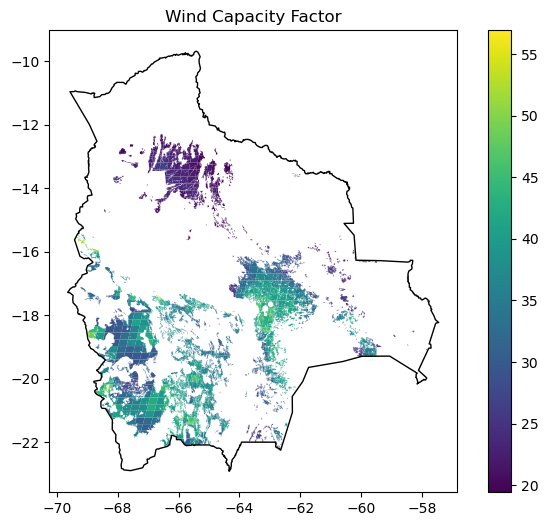

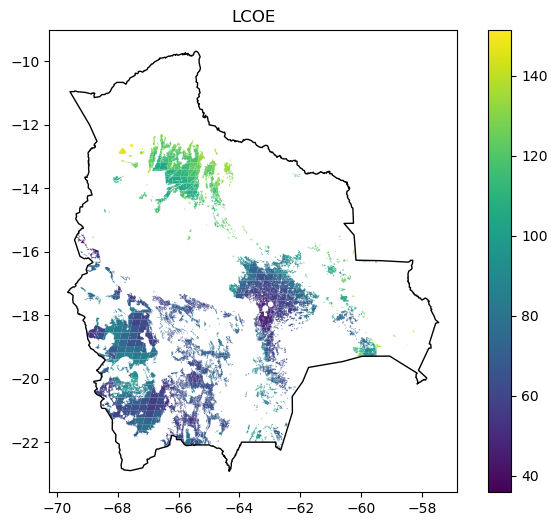

In [16]:
region_map(geo_dataframe=gdf3wind, country='Bolivia', key_column="CF100m", map_title="Wind Capacity Factor")
region_map(geo_dataframe=gdf3wind, country='Bolivia', key_column="LCOE-MWh", map_title="LCOE")


===== Correlation Analysis: CF100m vs LCOE-MWh =====
Pearson r:     -0.9557  (p = 0.0000e+00)
Spearman rho:  -0.9837  (p = 0.0000e+00)



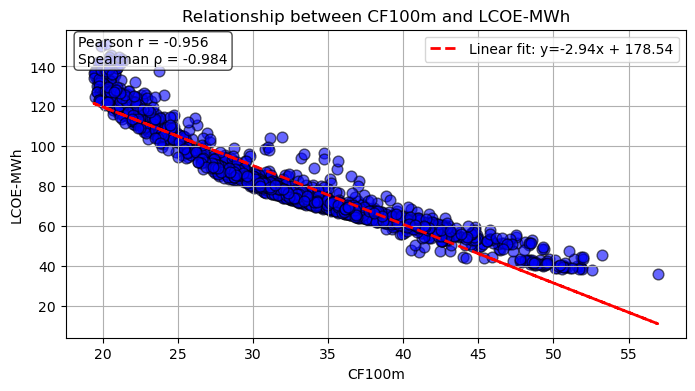


===== Correlation Analysis: TD_Dist_gf vs LCOE-MWh =====
Pearson r:     0.5621  (p = 3.7703e-128)
Spearman rho:  0.4728  (p = 4.8339e-86)



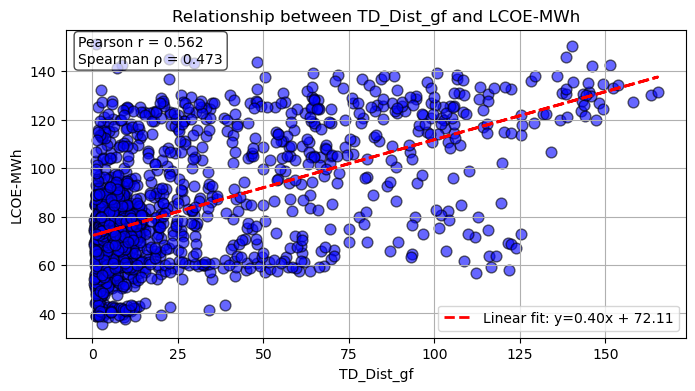


===== Correlation Analysis: TD_Dist_gf vs CF100m =====
Pearson r:     -0.4184  (p = 6.7574e-66)
Spearman rho:  -0.3846  (p = 4.0951e-55)



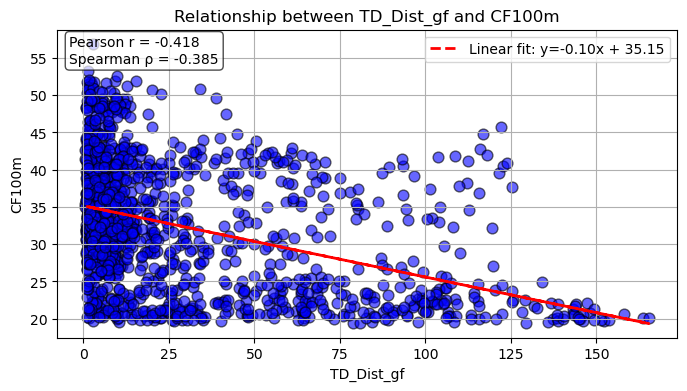


===== Correlation Analysis: Elev_mean vs LCOE-MWh =====
Pearson r:     -0.5530  (p = 2.7997e-123)
Spearman rho:  -0.5694  (p = 3.2022e-132)



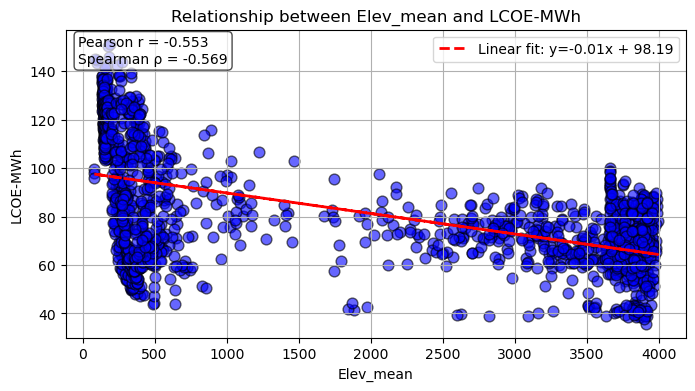

In [17]:
plot_variable_relationship(dataframe=gdf3wind, col_x='CF100m',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf3wind, col_x='TD_Dist_gf',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf3wind, col_x='TD_Dist_gf',col_y='CF100m',add_regression=True)
plot_variable_relationship(dataframe=gdf3wind, col_x='Elev_mean',col_y='LCOE-MWh',add_regression=True)

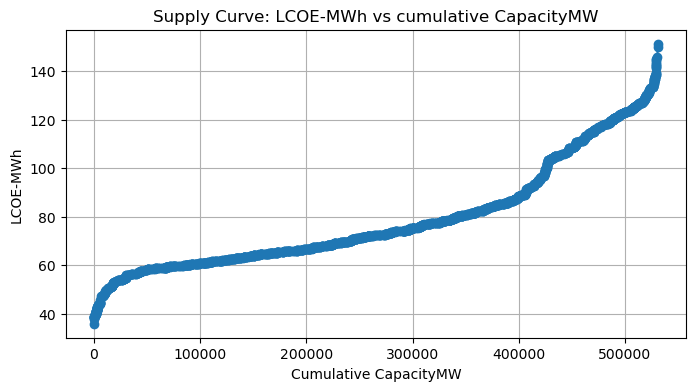

In [18]:
#generate_supply_curve(geo_dataframe=gdf3wind,ranking_col="CF100m",accumulation_col="CapacityMW",ascending=False)
generate_supply_curve(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",ascending=True)
#generate_supply_curve(geo_dataframe=gdf3wind,ranking_col="TD_Dist_gf",accumulation_col="CapacityMW",ascending=True)
#generate_supply_curve(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="Y_GWh100m",ascending=True)

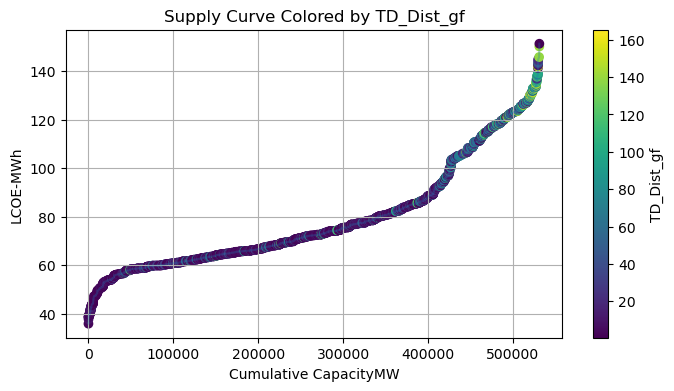

,LCOE-MWh,CapacityMW,TD_Dist_gf,cumulative
0,35.807940,22.049100,2.729616,22.049100
1,37.661271,103.604203,9.695002,125.653303
2,38.376153,37.191252,9.147794,162.844555
3,38.563312,31.081261,6.507709,193.925816
4,38.653960,20.720841,4.601181,214.646657
...,...,...,...,...
1525,144.498000,35.862993,27.268907,529601.247161
1526,144.937603,24.174314,22.364636,529625.421475
1527,145.885739,1076.421105,138.513548,530701.842580
1528,150.239293,254.760079,140.290202,530956.602659


In [19]:
generate_supply_curve_color(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="TD_Dist_gf", ascending=True)
#generate_supply_curve_color(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ascending=True)

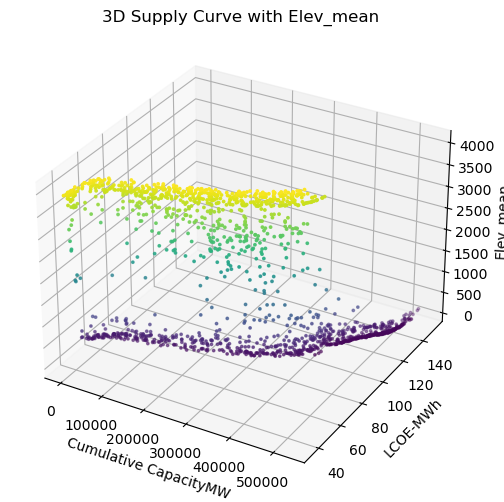

,LCOE-MWh,CapacityMW,Elev_mean,cumulative
0,35.807940,22.049100,3909.555556,22.049100
1,37.661271,103.604203,3894.531250,125.653303
2,38.376153,37.191252,3864.615385,162.844555
3,38.563312,31.081261,3786.333333,193.925816
4,38.653960,20.720841,3841.571429,214.646657
...,...,...,...,...
1525,144.498000,35.862993,99.230769,529601.247161
1526,144.937603,24.174314,83.111111,529625.421475
1527,145.885739,1076.421105,180.290859,530701.842580
1528,150.239293,254.760079,172.795455,530956.602659


In [20]:
generate_supply_curve_3d(geo_dataframe=gdf3wind, ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ascending=True)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11080\2190700042.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cmap, n_bands)


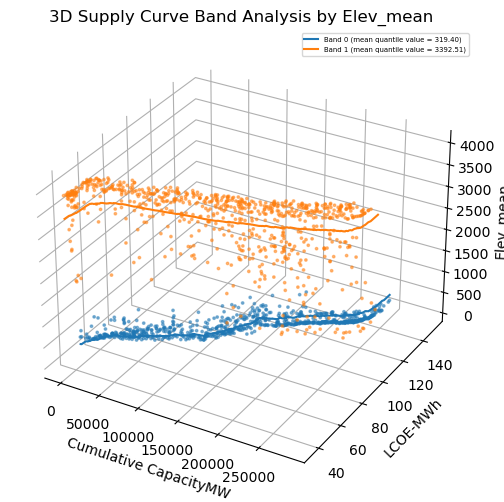

In [21]:
data_test = generate_supply_curve_3d_band_analysis(geo_dataframe=gdf3wind, 
                                       ranking_col="LCOE-MWh",
                                       accumulation_col="CapacityMW",
                                       third_col="Elev_mean", 
                                       n_bands=2, ascending=True, 
                                       cmap="viridis")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11080\3988394567.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cmap, n_bands)


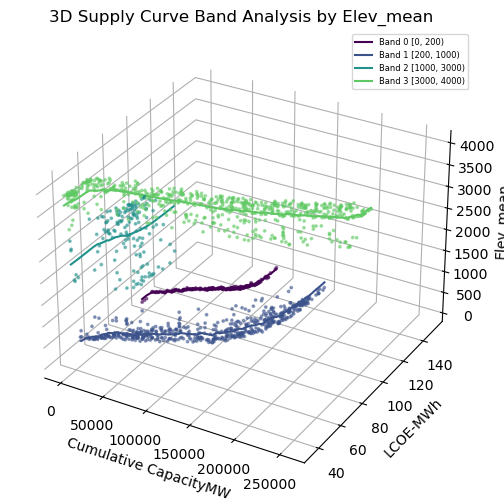

,LCOE-MWh,CapacityMW,Elev_mean,band
0,49.833877,449.250405,345.340136,1
1,48.110323,616.278976,410.770000,1
2,44.250948,67.475558,493.705882,1
3,49.621557,818.838475,336.812057,1
4,47.135974,742.197930,394.592453,1
...,...,...,...,...
1525,60.620560,180.377574,3411.984375,3
1526,80.487898,47.286021,272.200000,1
1527,66.456836,1188.791817,3788.155718,3
1528,87.246447,23.377359,277.666667,1


In [60]:
band_edges = [0, 200, 1000, 3000, 4000, np.inf]

generate_supply_curve_3d_definedband_analysis(
    geo_dataframe=gdf3wind,
    ranking_col="LCOE-MWh",
    accumulation_col="CapacityMW",
    third_col="Elev_mean",
    band_edges=band_edges
)


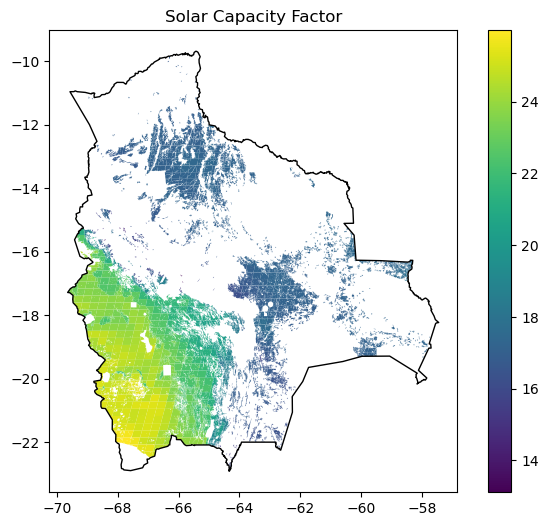

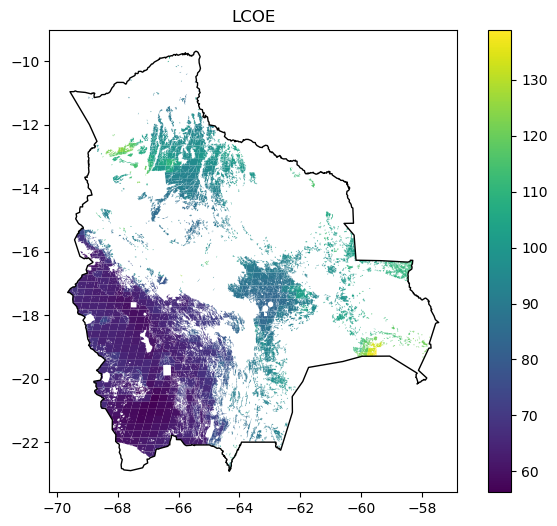

In [22]:
region_map(geo_dataframe=gdf3solar, country='Bolivia', key_column="CF", map_title="Solar Capacity Factor")
region_map(geo_dataframe=gdf3solar, country='Bolivia', key_column="LCOE-MWh", map_title="LCOE")


===== Correlation Analysis: CF vs LCOE-MWh =====
Pearson r:     -0.8528  (p = 0.0000e+00)
Spearman rho:  -0.6700  (p = 0.0000e+00)



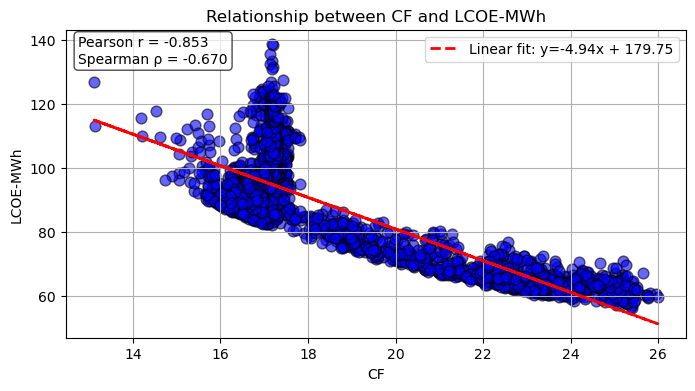


===== Correlation Analysis: TD_Dist_gf vs LCOE-MWh =====
Pearson r:     0.5262  (p = 7.6304e-194)
Spearman rho:  0.6152  (p = 2.3732e-283)



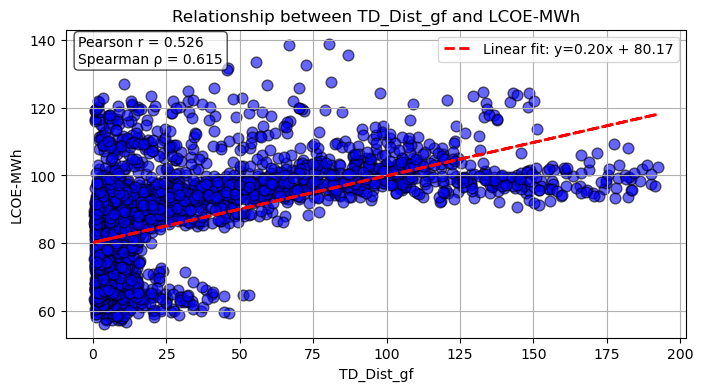


===== Correlation Analysis: TD_Dist_gf vs CF =====
Pearson r:     -0.3569  (p = 1.3906e-82)
Spearman rho:  -0.2597  (p = 3.2329e-43)



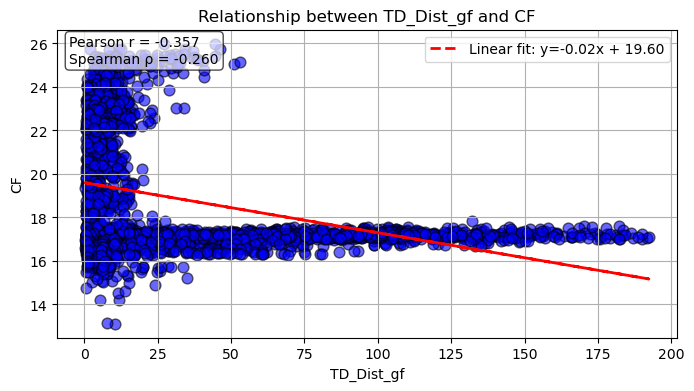


===== Correlation Analysis: Elev_mean vs LCOE-MWh =====
Pearson r:     -0.8349  (p = 0.0000e+00)
Spearman rho:  -0.7560  (p = 0.0000e+00)



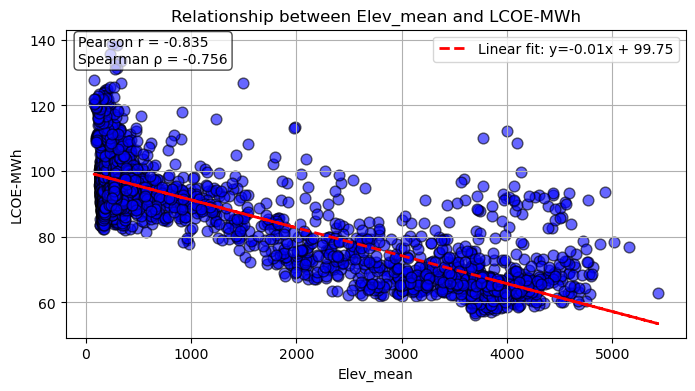

In [23]:
plot_variable_relationship(dataframe=gdf3solar, col_x='CF',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf3solar, col_x='TD_Dist_gf',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf3solar, col_x='TD_Dist_gf',col_y='CF',add_regression=True)
plot_variable_relationship(dataframe=gdf3solar, col_x='Elev_mean',col_y='LCOE-MWh',add_regression=True)

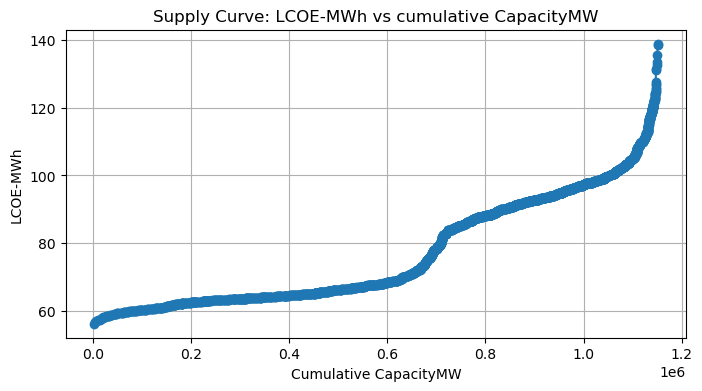

In [24]:
#generate_supply_curve(geo_dataframe=gdf3solar,ranking_col="CF",accumulation_col="CapacityMW",ascending=False)
generate_supply_curve(geo_dataframe=gdf3solar,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",ascending=True)
#generate_supply_curve(geo_dataframe=gdf3solar,ranking_col="TD_Dist_gf",accumulation_col="CapacityMW",ascending=True)
#generate_supply_curve(geo_dataframe=gdf3solar,ranking_col="LCOE-MWh",accumulation_col="Y_GWh",ascending=True)

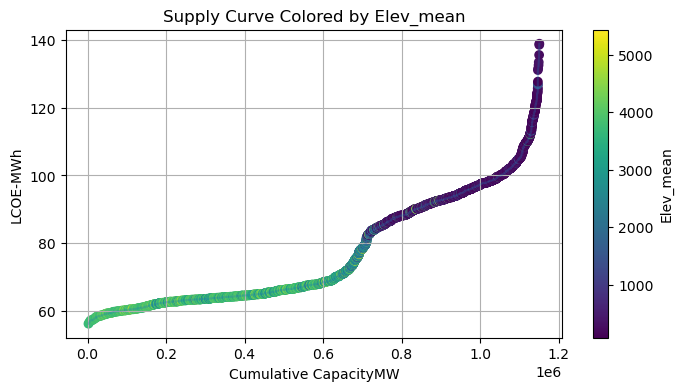

,LCOE-MWh,CapacityMW,Elev_mean,cumulative
0,56.257202,2369.235396,3692.341564,2.369235e+03
1,56.682272,2369.235396,3695.418381,4.738471e+03
2,57.171748,2365.955069,3844.538571,7.104426e+03
3,57.298734,2369.235396,3693.458689,9.473661e+03
4,57.306534,2368.756127,3781.360399,1.184242e+04
...,...,...,...,...
2718,132.532211,1043.833354,278.813665,1.149202e+06
2719,133.418171,427.113385,337.858209,1.149629e+06
2720,135.539316,952.767024,231.826389,1.150582e+06
2721,138.520358,274.671407,300.463415,1.150856e+06


In [25]:
#generate_supply_curve_color(geo_dataframe=gdf3solar,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="TD_Dist_gf", ascending=True)
generate_supply_curve_color(geo_dataframe=gdf3solar,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ascending=True)

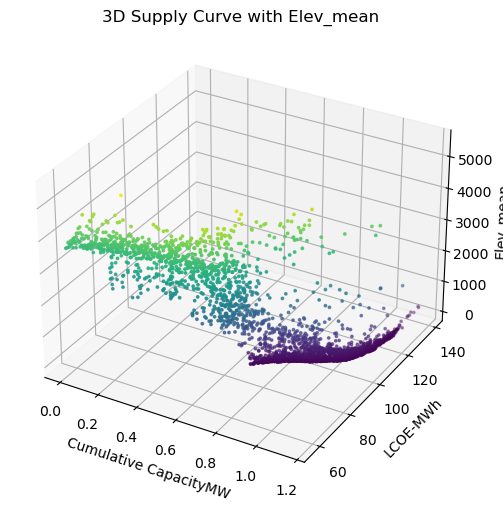

,LCOE-MWh,CapacityMW,Elev_mean,cumulative
0,56.257202,2369.235396,3692.341564,2.369235e+03
1,56.682272,2369.235396,3695.418381,4.738471e+03
2,57.171748,2365.955069,3844.538571,7.104426e+03
3,57.298734,2369.235396,3693.458689,9.473661e+03
4,57.306534,2368.756127,3781.360399,1.184242e+04
...,...,...,...,...
2718,132.532211,1043.833354,278.813665,1.149202e+06
2719,133.418171,427.113385,337.858209,1.149629e+06
2720,135.539316,952.767024,231.826389,1.150582e+06
2721,138.520358,274.671407,300.463415,1.150856e+06


In [26]:
generate_supply_curve_3d(geo_dataframe=gdf3solar, ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ascending=True)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11080\2190700042.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cmap, n_bands)


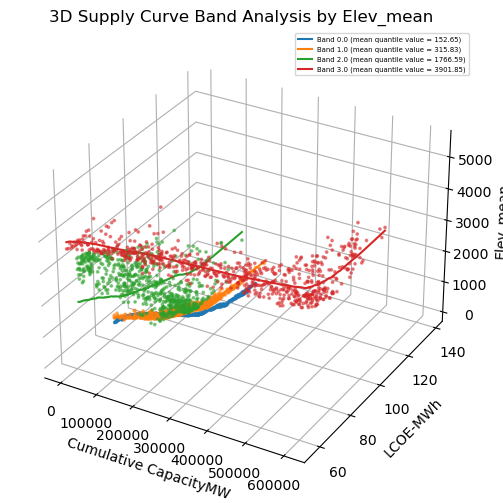

In [49]:
data_test = generate_supply_curve_3d_band_analysis(geo_dataframe=gdf3solar, 
                                       ranking_col="LCOE-MWh",
                                       accumulation_col="CapacityMW",
                                       third_col="Elev_mean", 
                                       n_bands=4, ascending=True, 
                                       cmap="viridis")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11080\3988394567.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cmap, n_bands)


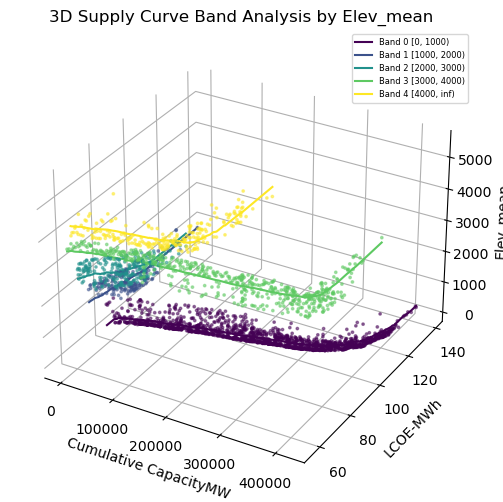

,LCOE-MWh,CapacityMW,Elev_mean,band
0,60.544012,1067.784224,3869.358491,3
1,61.805877,1465.201730,3909.128266,3
2,62.771288,2062.505114,3844.452303,3
3,63.790700,2344.963112,3875.543228,3
4,64.224481,2361.780109,3953.544160,3
...,...,...,...,...
2718,98.392833,26.540821,607.600000,0
2719,97.437490,66.799370,469.650000,0
2720,97.746462,307.157819,370.400000,0
2721,126.878497,39.363915,1496.916667,1


In [56]:
band_edges = [0, 1000, 2000, 3000, 4000, np.inf]

generate_supply_curve_3d_definedband_analysis(
    geo_dataframe=gdf3solar,
    ranking_col="LCOE-MWh",
    accumulation_col="CapacityMW",
    third_col="Elev_mean",
    band_edges=band_edges
)


## Data analysis (for screened or s4 data)

In [28]:
gdf4wind = gpd.read_file(S4_MSR_wind_file)
gdf4solar = gpd.read_file(S4_MSR_pv_file)

#check cordinate reference system and change it to WGS84 ellipsoid
gdf4wind = gdf4wind.to_crs("EPSG:4326")
gdf4solar = gdf4solar.to_crs("EPSG:4326")
#gdf4solar.crs

In [29]:
gdf4solar.info()
gdf4solar.columns
#gdf3wind.info()
#gdf3wind.columns

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         127 non-null    int64   
 1   AreakM2     127 non-null    float64 
 2   CapacityMW  127 non-null    float64 
 3   RoadDist    127 non-null    float64 
 4   T_Dist_gf   127 non-null    float64 
 5   D_Dist_gf   127 non-null    float64 
 6   TD_Dist_gf  127 non-null    float64 
 7   SubstnDist  127 non-null    float64 
 8   Load_dst    127 non-null    float64 
 9   City_name   127 non-null    object  
 10  City_Pop    127 non-null    float64 
 11  CtLst100kM  102 non-null    object  
 12  CtCnt100kM  127 non-null    int64   
 13  PopIn100kM  127 non-null    float64 
 14  Elev_mean   127 non-null    float64 
 15  Elev_max    127 non-null    float64 
 16  Elev_centr  127 non-null    float64 
 17  CtryName    127 non-null    object  
 18  GHIkWhm2d   127 non-null    object  
 19  

Index(['FID', 'AreakM2', 'CapacityMW', 'RoadDist', 'T_Dist_gf', 'D_Dist_gf',
       'TD_Dist_gf', 'SubstnDist', 'Load_dst', 'City_name', 'City_Pop',
       'CtLst100kM', 'CtCnt100kM', 'PopIn100kM', 'Elev_mean', 'Elev_max',
       'Elev_centr', 'CtryName', 'GHIkWhm2d', 'RawERA_GHI', 'CorAdderWh', 'CF',
       'Y_GWh', 'sLCOE-MWh', 'tLCOE-MWh', 'tCAPEX-kW', 'rLCOE-MWh',
       'rCAPEX-kW', 'LCOE-MWh', 'trCAPEX-kW', 'geometry'],
      dtype='object')

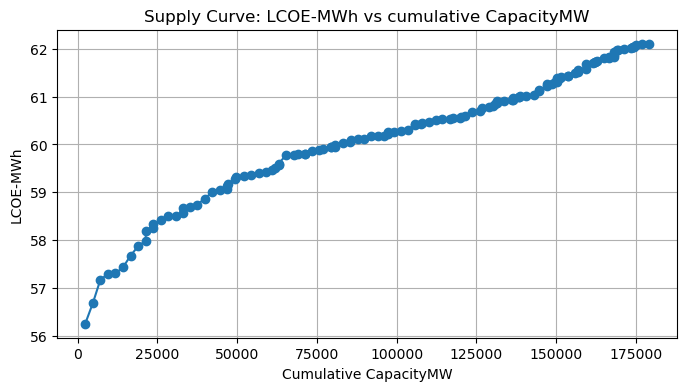

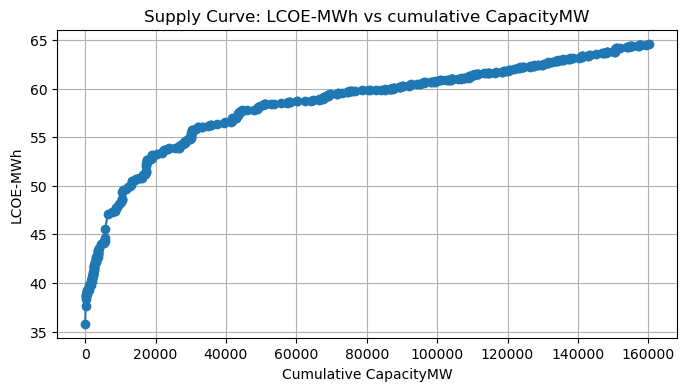

In [30]:
generate_supply_curve(geo_dataframe=gdf4solar,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",ascending=True)
generate_supply_curve(geo_dataframe=gdf4wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",ascending=True)

## Sensitivity analysis of supply curves

In [80]:
#Load prescreened MSR shapes for sensitivy analysis (with LCOE and CAPEX values defined) 
S3_MSR_pv_file_2021 = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_localcosts2021\SolarPV_prescreen.shp'
S3_MSR_wind_file_2021 = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_localcosts2021\Wind_prescreen.shp'

S3_MSR_pv_file_2050 = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_localcosts2050\SolarPV_prescreen.shp'
S3_MSR_wind_file_2050 = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_localcosts2050\Wind_prescreen.shp'

In [81]:
gdf3wind2021 = gpd.read_file(S3_MSR_wind_file_2021)
gdf3solar2021 = gpd.read_file(S3_MSR_pv_file_2021)

gdf3wind2050 = gpd.read_file(S3_MSR_wind_file_2050)
gdf3solar2050 = gpd.read_file(S3_MSR_pv_file_2050)

In [84]:
def generate_supply_curve_color_modified(
    geo_dataframe, ranking_col, accumulation_col, third_col,
    ascending=True, cmap="viridis", ax=None, label=None, linestyle="-", scatter_size=15
):
    df = geo_dataframe[[ranking_col, accumulation_col, third_col]].copy()
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)
    df["cumulative"] = df[accumulation_col].cumsum()

    # Create axis only if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    sc = ax.scatter(
        df["cumulative"],
        df[ranking_col],
        c=df[third_col],
        cmap=cmap,
        s=scatter_size,
        alpha=0.7
    )

    ax.plot(
        df["cumulative"],
        df[ranking_col],
        linestyle=linestyle,
        linewidth=1.5,
        alpha=0.9,
        label=label
    )

    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(ranking_col)
    ax.grid(True)

    return df, sc


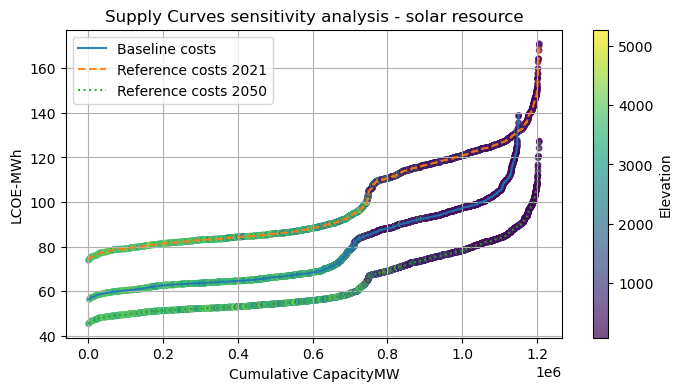

In [88]:
fig, ax = plt.subplots(figsize=(8, 4))

df1, sc1 = generate_supply_curve_color_modified(geo_dataframe=gdf3solar,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Baseline costs", linestyle="-", scatter_size=15,ascending=True)
df2, sc2 = generate_supply_curve_color_modified(geo_dataframe=gdf3solar2021,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Reference costs 2021", linestyle="--", scatter_size=15,ascending=True)
df3, sc3 = generate_supply_curve_color_modified(geo_dataframe=gdf3solar2050,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Reference costs 2050", linestyle=":", scatter_size=15, ascending=True)

# One shared colorbar (use last scatter)
cbar = plt.colorbar(sc3, ax=ax)
cbar.set_label("Elevation")

ax.set_title("Supply Curves sensitivity analysis - solar resource")
ax.legend()
plt.show()

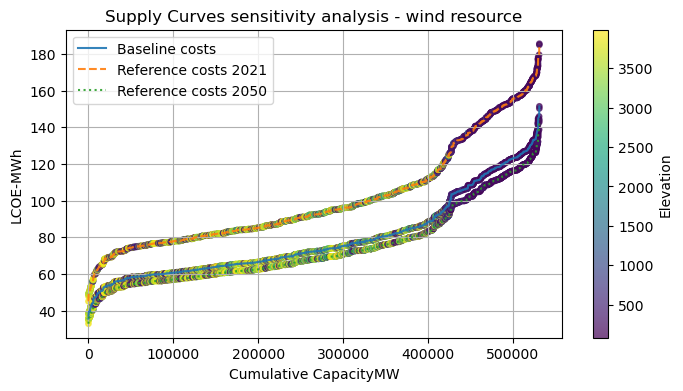

In [90]:
fig, ax = plt.subplots(figsize=(8, 4))

df1, sc1 = generate_supply_curve_color_modified(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Baseline costs", linestyle="-", scatter_size=15,ascending=True)
df2, sc2 = generate_supply_curve_color_modified(geo_dataframe=gdf3wind2021,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Reference costs 2021", linestyle="--", scatter_size=15,ascending=True)
df3, sc3 = generate_supply_curve_color_modified(geo_dataframe=gdf3wind2050,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Reference costs 2050", linestyle=":", scatter_size=15, ascending=True)

# One shared colorbar (use last scatter)
cbar = plt.colorbar(sc3, ax=ax)
cbar.set_label("Elevation")

ax.set_title("Supply Curves sensitivity analysis - wind resource")
ax.legend()
plt.show()